# Laboratorio 4: Simulación de eventos discretos
## 5.3 Inventario probabilístico

**Curso:** Simulación Computacional · Universidad de los Llanos · **Estudiante:** Duván Felipe Baquero · **Código:** 160005002

Implementación del modelo de inventario probabilístico de la sección 5.6 de [Rios08], con la misma estructura de
los ejemplos de colas de los numerales 5.1 y 5.2: una lista de sucesos `TSuc`, una rutina por tipo de suceso,
variables de estado, contadores y un bucle principal que ejecuta siempre el suceso más próximo.

### El modelo

Un almacén vende un producto a $r$ por unidad. Los clientes llegan según un proceso de Poisson de parámetro
$\lambda$ y cada uno pide una cantidad aleatoria con distribución $G$. Si hay suficiente se le vende todo; si no,
se le vende lo que queda y el resto de la venta se pierde. La política de pedidos es la del libro: **cuando el
nivel del inventario $x$ queda por debajo de $p$ y no hay ningún pedido pendiente, se piden $P - x$ unidades**,
para que el inventario vuelva a $P$. El pedido tarda $L$ unidades de tiempo en llegar y se paga al recibirlo.
Mantener el inventario cuesta una cantidad por unidad de producto y unidad de tiempo.

| Símbolo | Significado | Valor |
|---|---|---|
| $P_0$ | inventario inicial | 20 |
| $P$ | nivel máximo de inventario | 100 |
| $p$ | nivel por debajo del cual se hace un pedido | 20 |
| $L$ | tiempo que tarda en llegar un pedido | 5 |
| $h$ | valor a pagar por una unidad del producto: $c(y) = h\,y$ | 100 |
| $r$ | precio de venta al público | 150 |
| $\lambda$ | tasa de llegada de clientes (proceso de Poisson) | 1 cliente por unidad de tiempo (ver abajo) |
| $G$ | demanda de cada cliente | uniforme discreta en $\{1, 2, 3, 4, 5\}$ |
| $a$ | costo de almacenamiento por unidad y por unidad de tiempo | 1 |
| $T$ | horizonte de la simulación | 100 |

**Sobre los parámetros.** Los seis primeros valores son los de la guía. Hay dos cosas que aclarar:

- La guía describe $p$ como "cantidad de producto a pedir si no hay pedidos pendientes", pero en el modelo del
  libro $p$ es el **nivel de reorden** y la cantidad que se pide es $P - x$ (así aparece en la Figura 1 de la
  guía, tomada de la Figura 5.9 del libro, donde los pedidos se marcan como $P - x_1$ y $P - x_2$). Se sigue el
  libro. Con $P_0 = p = 20$ el primer cliente ya deja el inventario por debajo de $p$ y dispara el primer pedido.
- En el libro $h$ es el costo de almacenamiento y el costo del pedido es una función aparte $c(y)$. La guía
  define $h = 100$ como el valor a pagar por unidad, así que aquí $c(y) = h\,y = 100\,y$. Para el costo de
  almacenamiento, que la guía no da, se usa $a = 1$ por unidad y unidad de tiempo.
- La guía deja $\lambda$ como parámetro sin valor, y tampoco fija $G$ ni $T$. Se toma $\lambda = 1$,
  demanda uniforme entre 1 y 5 unidades (media 3) y $T = 100$ para la simulación principal, y al final se
  repite con varios valores de $\lambda$ para ver cómo cambian las medidas.

**Correcciones al pseudocódigo del libro.** Al implementarlo aparecen tres detalles:

1. En `Llegada_cliente` el libro escribe `Si demanda < x` para la venta completa, pero el texto dice "mayor o
   igual". Con `<`, un cliente que pide exactamente lo que queda se contaría como no satisfecho. Se usa `<=`.
2. En `Llegada_pedido` aparece `Si var_aux > 0`, variable que no existe; es `var_nivel0`.
3. El libro guarda `var_nivel0 = t` cada vez que un cliente encuentra el inventario insuficiente, también si ya
   estaba en cero, con lo que pierde el tramo anterior. Aquí se guarda solo cuando el inventario **pasa** a
   cero (también si llega a cero con una venta completa).

Además, si el último suceso ocurre antes de $T$ se acumula el costo de almacenamiento y el tiempo en cero hasta
$T$, y el porcentaje de inventario en cero se calcula sobre $\max(T, t_{final})$.

**Medida adicional.** El beneficio del libro, $R - C - H$, cobra completo cualquier pedido que llegue al final
aunque sus unidades no alcancen a venderse. Para separar ese efecto de borde se reporta también un
*beneficio ajustado*, $R - C - H + h\,(x_{final} - P_0)$, que valora a costo la diferencia entre el inventario
con que se termina y el inventario con que se empezó.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)

def guardar(nombre):
    if os.path.isdir("figuras"):
        plt.savefig(f"figuras/{nombre}.pdf", bbox_inches="tight")

In [2]:
# ----- parámetros de la guía -----
P0 = 20        # inventario inicial
P  = 100       # nivel máximo de inventario
p  = 20        # nivel de reorden
L  = 5         # tiempo de llegada de un pedido
h  = 100       # valor a pagar por unidad del producto
r  = 150       # precio de venta al público
# ----- parámetros que la guía no fija -----
lam = 1.0      # clientes por unidad de tiempo
a   = 1.0      # costo de almacenamiento por unidad y unidad de tiempo
T   = 100.0    # horizonte de simulación
DEMANDA_MIN, DEMANDA_MAX = 1, 5

M = 999999.0

def c(y):
    # costo de un pedido de y unidades
    return h * y

def generar_demanda():
    return np.random.randint(DEMANDA_MIN, DEMANDA_MAX + 1)

### Variables del modelo (las mismas del libro)

- Estado: $x$ = unidades en inventario; $y$ = unidades del pedido pendiente ($y = 0$ si no hay).
- Tiempo: $t$ = reloj de la simulación; `var_nivel0` = instante en que el inventario llegó a cero.
- Contadores: $C$ = costo total por pedidos; $H$ = costo total por almacenamiento; $R$ = ingresos por ventas;
  $N_{C+}$ y $N_{C-}$ = clientes con demanda satisfecha completamente y no; $t_0$ = tiempo total con inventario
  en cero.
- Lista de sucesos: `TSuc = {tC, tP}`, instante de la próxima llegada de un cliente y de un pedido.

### Rutinas de sucesos

In [3]:
def registrar():
    # guarda el estado después de cada suceso para las gráficas
    traza["t"].append(t); traza["x"].append(x); traza["y"].append(y)
    traza["H"].append(H); traza["C"].append(C); traza["R"].append(R)

def Llegada_cliente(tsuc):
    global H, t, R, x, y, N_mas, N_menos, var_nivel0
    H = H + (tsuc - t) * a * x
    t = tsuc
    demanda = generar_demanda()
    if demanda <= x:                               # venta completa (corrección 1)
        R = R + demanda * r
        x = x - demanda
        N_mas = N_mas + 1
        if x == 0:
            var_nivel0 = t
        clientes.append((t, demanda, demanda))
    else:                                          # venta parcial
        vendidas = x
        R = R + x * r
        if x > 0:                                  # solo si PASA a cero (corrección 3)
            var_nivel0 = t
        x = 0
        N_menos = N_menos + 1
        clientes.append((t, demanda, vendidas))
    if x < p and y == 0:                           # política de pedidos
        y = P - x
        TSuc["tP"] = t + L
        pedidos.append((t, y))
    Y = np.random.exponential(1 / lam)             # tiempo hasta el siguiente cliente, Exp(lambda)
    if t + Y < T:
        TSuc["tC"] = t + Y
    registrar()

def Llegada_pedido(tsuc):
    global H, t, C, x, y, t0, var_nivel0
    H = H + (tsuc - t) * a * x
    t = tsuc
    C = C + c(y)
    if x == 0 and var_nivel0 is not None:          # corrección 2: var_nivel0 (el libro dice var_aux)
        t0 = t0 + (t - var_nivel0)
        var_nivel0 = None
    x = x + y
    y = 0
    llegadas_pedido.append(t)
    registrar()

### Programa principal

Igual al del libro: el primer suceso es la llegada de un cliente; dentro del bucle se atiende el suceso más
próximo y, al final, se calculan las medidas de desempeño con los contadores.

In [4]:
def simular(semilla=None):
    global x, y, N_menos, N_mas, C, R, H, t, tsuc, t0, var_nivel0, TSuc
    global traza, clientes, pedidos, llegadas_pedido
    if semilla is not None:
        np.random.seed(semilla)
    x, y = P0, 0
    N_menos = N_mas = 0
    C = R = H = 0.0
    TSuc = {"tC": M, "tP": M}
    t = tsuc = t0 = 0.0
    var_nivel0 = None
    traza = {"t": [0.0], "x": [x], "y": [y], "H": [0.0], "C": [0.0], "R": [0.0]}
    clientes, pedidos, llegadas_pedido = [], [], []

    Z = np.random.exponential(1 / lam)
    if Z > T:
        return {"Beneficio": 0.0, "% clientes satisfechos": 0.0, "% inventario en cero": 0.0}
    Llegada_cliente(Z)
    while TSuc["tP"] != M or TSuc["tC"] != M:
        if TSuc["tC"] < TSuc["tP"]:
            tsuc = TSuc["tC"]; TSuc["tC"] = M
            Llegada_cliente(tsuc)
        else:
            tsuc = TSuc["tP"]; TSuc["tP"] = M
            Llegada_pedido(tsuc)

    horizonte = max(T, t)
    if t < T:                                      # cierre del periodo hasta T
        H = H + (T - t) * a * x
        if x == 0 and var_nivel0 is not None:
            t0 = t0 + (T - var_nivel0)
        t = T
        registrar()

    beneficio = R - C - H
    return {"Beneficio": beneficio,
            "% clientes satisfechos": 100 * N_mas / (N_mas + N_menos),
            "% inventario en cero": 100 * t0 / horizonte,
            "Ingresos R": R, "Costo pedidos C": C, "Costo almacenamiento H": H,
            "Clientes": N_mas + N_menos, "Satisfechos": N_mas, "No satisfechos": N_menos,
            "Pedidos": len(pedidos), "Inventario final": x, "Duración": horizonte,
            "Beneficio ajustado": beneficio + h * (x - P0)}

---
### Simulación principal ($\lambda = 1$, $T = 100$)

In [5]:
res = simular(semilla=160005002 % 2**32)
medidas = pd.Series(res)
print(f"Beneficio                      : {res['Beneficio']:,.2f}")
print(f"Porcentaje de clientes satisfechos: {res['% clientes satisfechos']:.2f} %")
print(f"Porcentaje de inventario en cero  : {res['% inventario en cero']:.2f} %")
print(f"(Beneficio ajustado por inventario final: {res['Beneficio ajustado']:,.2f})")
medidas.to_frame("Valor")

Beneficio                      : 1,121.70
Porcentaje de clientes satisfechos: 95.96 %
Porcentaje de inventario en cero  : 1.66 %
(Beneficio ajustado por inventario final: 8,021.70)


,Valor
Beneficio,1121.7021
% clientes satisfechos,95.9596
% inventario en cero,1.6594
Ingresos R,38700.0000
Costo pedidos C,32700.0000
Costo almacenamiento H,4878.2979
Clientes,99.0000
Satisfechos,95.0000
No satisfechos,4.0000
Pedidos,4.0000


In [6]:
print("Pedidos realizados (instante, unidades pedidas = P - x):")
for (tp, yp), tl in zip(pedidos, llegadas_pedido):
    print(f"  pedido en t = {tp:7.3f}: {yp:3d} unidades, llega en t = {tl:7.3f}, costo = {c(yp):,.0f}")
no_sat = [(round(tc, 3), d, v) for tc, d, v in clientes if v < d]
print(f"\nClientes no satisfechos (instante, demanda, unidades vendidas): {no_sat}")

Pedidos realizados (instante, unidades pedidas = P - x):
  pedido en t =   0.682:  81 unidades, llega en t =   5.682, costo = 8,100
  pedido en t =  33.306:  81 unidades, llega en t =  38.306, costo = 8,100
  pedido en t =  67.905:  81 unidades, llega en t =  72.905, costo = 8,100
  pedido en t =  95.740:  84 unidades, llega en t = 100.740, costo = 8,400

Clientes no satisfechos (instante, demanda, unidades vendidas): [(37.133, 4, 0), (37.385, 2, 0), (37.414, 1, 0), (37.633, 4, 0)]


### Visualización de la evolución en el tiempo

La primera gráfica reproduce la idea de la Figura 1 de la guía (Figura 5.9 del libro) con los datos de la
simulación: el nivel del inventario baja a saltos con cada cliente; cuando queda por debajo de $p = 20$ se hace
un pedido de $P - x$ unidades (flecha) que llega $L = 5$ unidades de tiempo después (línea punteada) y sube el
inventario. Los tramos sombreados son los periodos con el inventario en cero.

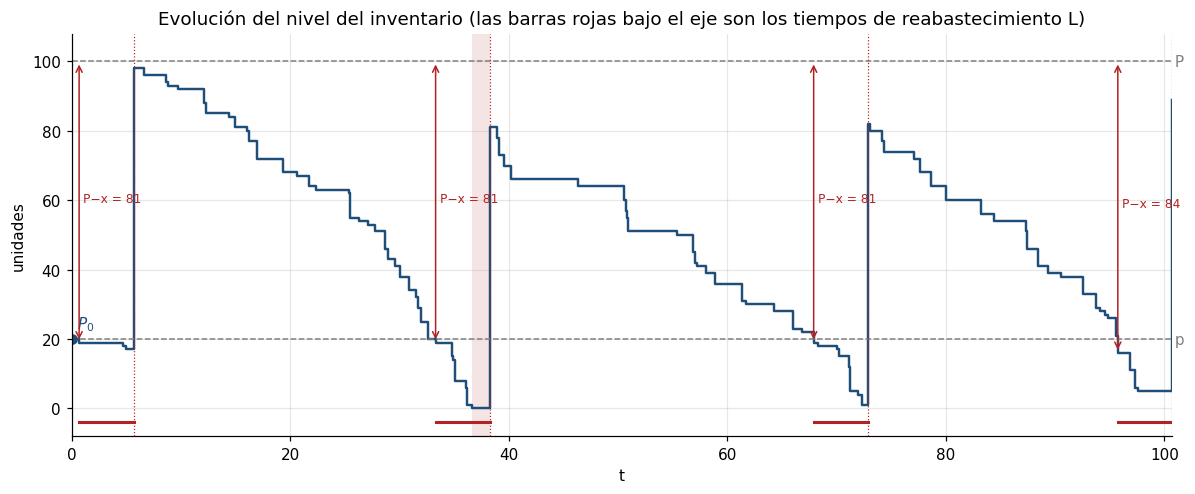

In [7]:
tt, xx = np.array(traza["t"]), np.array(traza["x"])

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.step(tt, xx, where="post", color="#1f4e79", lw=1.6, label="nivel del inventario x(t)")
ax.axhline(P, color="gray", ls="--", lw=1); ax.text(T * 1.005, P, " P", va="center", color="gray")
ax.axhline(p, color="gray", ls="--", lw=1); ax.text(T * 1.005, p, " p", va="center", color="gray")
ax.plot(0, P0, "o", color="#1f4e79"); ax.text(0.5, P0 + 3, "$P_0$", color="#1f4e79")
for (tp, yp), tl in zip(pedidos, llegadas_pedido):
    xp = P - yp
    ax.annotate("", xy=(tp, P), xytext=(tp, xp), arrowprops=dict(arrowstyle="<->", color="#b22222", lw=1))
    ax.text(tp + 0.4, (P + xp) / 2, f"P−x = {yp}", color="#b22222", fontsize=8)
    ax.plot([tp, tl], [-4, -4], color="#b22222", lw=2)
    ax.axvline(tl, color="#b22222", ls=":", lw=0.8)
# sombrear periodos en cero
en_cero = None
for ti, xi in zip(tt, xx):
    if xi == 0 and en_cero is None:
        en_cero = ti
    elif xi > 0 and en_cero is not None:
        ax.axvspan(en_cero, ti, color="#b22222", alpha=0.12, lw=0); en_cero = None
ax.set_xlim(0, max(tt)); ax.set_ylim(-8, P + 8)
ax.set_xlabel("t"); ax.set_ylabel("unidades")
ax.set_title("Evolución del nivel del inventario (las barras rojas bajo el eje son los tiempos de reabastecimiento L)")
plt.tight_layout(); guardar("53_nivel"); plt.show()

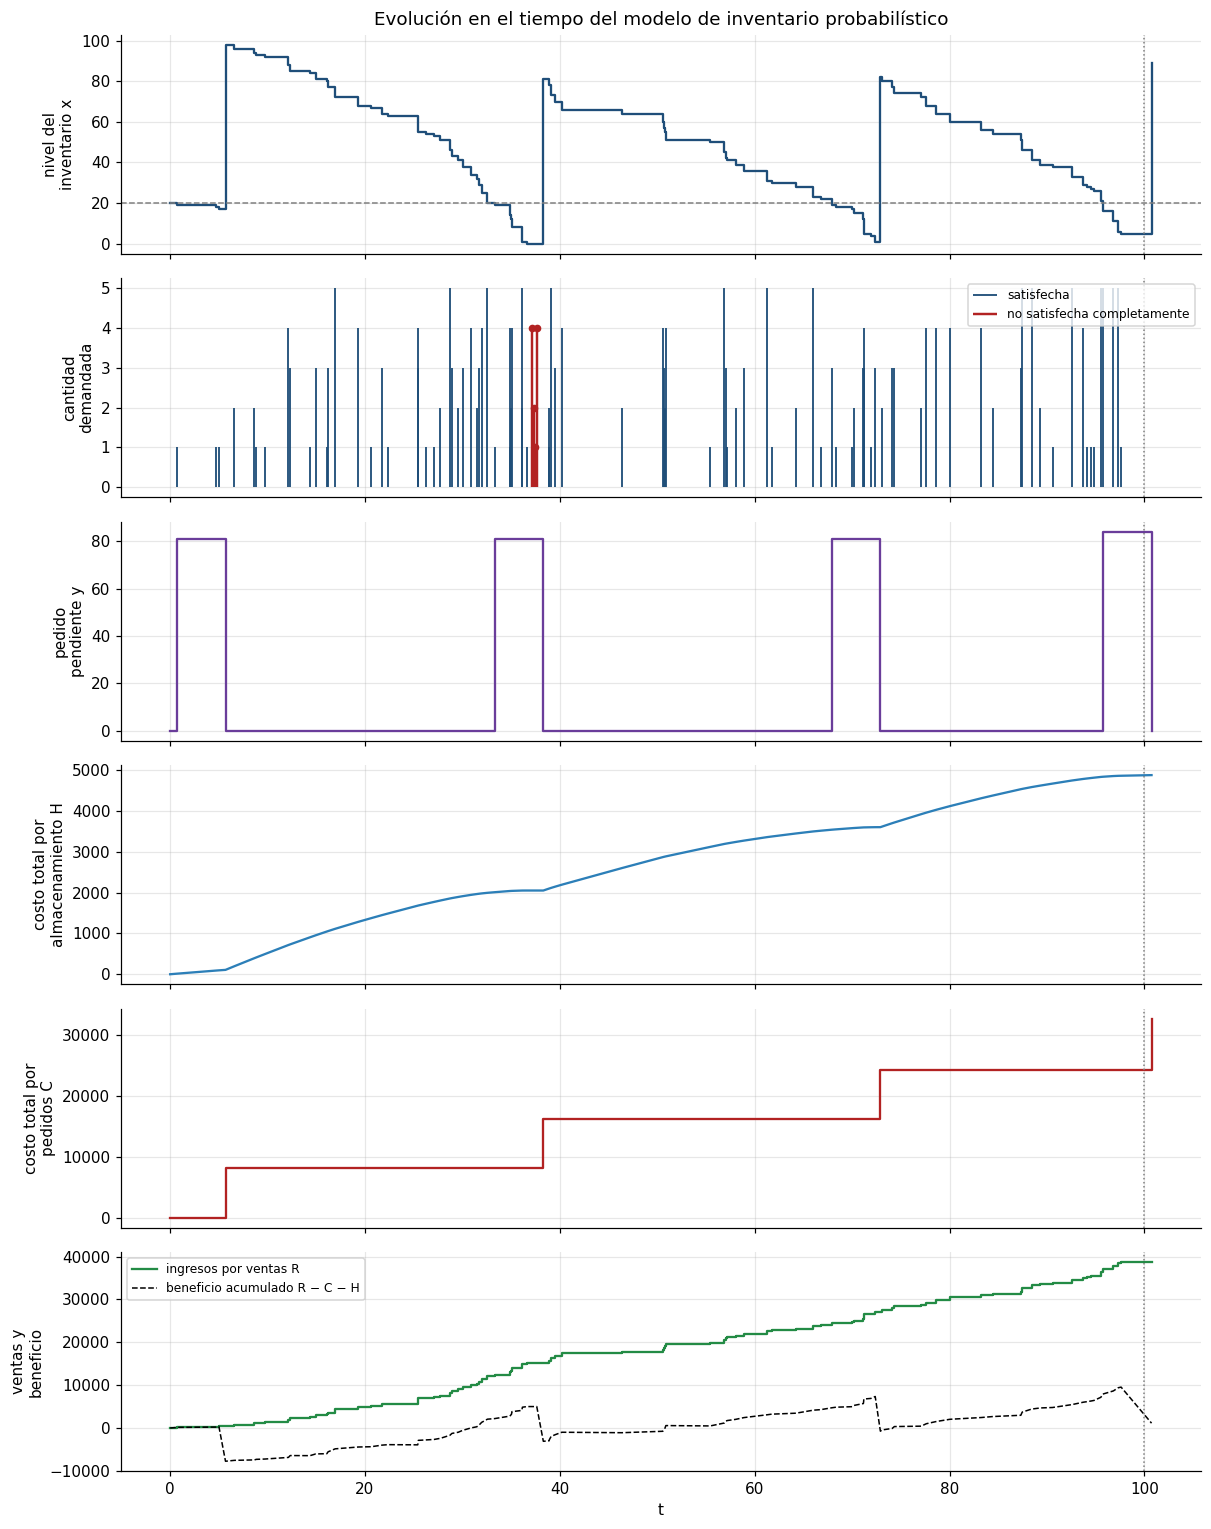

In [8]:
fig, axs = plt.subplots(6, 1, figsize=(11, 14), sharex=True)
axs[0].step(tt, xx, where="post", color="#1f4e79"); axs[0].axhline(p, color="gray", ls="--", lw=1)
axs[0].set_ylabel("nivel del\ninventario x")

tc = np.array([cl[0] for cl in clientes]); dc = np.array([cl[1] for cl in clientes]); vc = np.array([cl[2] for cl in clientes])
sat = vc == dc
axs[1].vlines(tc[sat], 0, dc[sat], color="#1f4e79", lw=1.2, label="satisfecha")
axs[1].vlines(tc[~sat], 0, dc[~sat], color="#b22222", lw=1.6, label="no satisfecha completamente")
axs[1].plot(tc[~sat], dc[~sat], "o", color="#b22222", ms=4)
axs[1].set_ylabel("cantidad\ndemandada"); axs[1].legend(loc="upper right", fontsize=8)

axs[2].step(tt, traza["y"], where="post", color="#6a3d9a"); axs[2].set_ylabel("pedido\npendiente y")
axs[3].plot(tt, traza["H"], color="#2c7fb8"); axs[3].set_ylabel("costo total por\nalmacenamiento H")
axs[4].step(tt, traza["C"], where="post", color="#b22222"); axs[4].set_ylabel("costo total por\npedidos C")
axs[5].step(tt, traza["R"], where="post", color="#238b45", label="ingresos por ventas R")
axs[5].plot(tt, np.array(traza["R"]) - np.array(traza["C"]) - np.array(traza["H"]), color="black", lw=1, ls="--",
            label="beneficio acumulado R − C − H")
axs[5].set_ylabel("ventas y\nbeneficio"); axs[5].legend(loc="upper left", fontsize=8)
axs[5].set_xlabel("t")
for ax in axs:
    ax.axvline(T, color="gray", ls=":", lw=1)
axs[0].set_title("Evolución en el tiempo del modelo de inventario probabilístico")
plt.tight_layout(); guardar("53_panel"); plt.show()


### Medidas de desempeño de la simulación principal

| Medida | Valor |
|---|---|
| Beneficio ($R - C - H$) | 1.121,70 |
| Porcentaje de clientes satisfechos | 95,96 % (95 de 99 clientes) |
| Porcentaje de inventario en cero | 1,66 % |

**Cómo se llega a ese beneficio.** Se vendieron 258 unidades, que dejaron $R = 38.700$. Se hicieron 4 pedidos
(81, 81, 81 y 84 unidades) que costaron $C = 32.700$, y mantener el inventario costó $H = 4.878{,}30$. El
beneficio parece bajo porque el cuarto pedido se hizo en $t = 95{,}74$ y llegó en $t = 100{,}74$, después de
cerrar el periodo. Se pagaron 8.400 por unidades que nunca se alcanzaron a vender, y la simulación terminó con
89 unidades en bodega. El beneficio ajustado, que valora a costo esa diferencia de inventario, es 8.021,70.
En el panel de ventas y beneficio se ve el efecto: el beneficio acumulado cae de golpe en $t = 100{,}74$.

**El único desabastecimiento** fue entre $t = 37{,}13$ y $t = 38{,}31$. El segundo pedido se hizo en
$t = 33{,}31$, y en las cinco unidades de tiempo que tardó en llegar la demanda se comió las 19 unidades que quedaban. Los
4 clientes no satisfechos llegaron en ese hueco y no se les vendió nada. Fuera de ese episodio la política
funcionó bien: los otros tres pedidos llegaron cuando aún quedaban 17, 1 y 5 unidades en bodega.


---
### Réplicas de la simulación principal

El libro cierra la sección diciendo que hay que replicar la simulación para obtener varias estimaciones de las
medidas de interés. Se hacen 30 réplicas con $\lambda = 1$ y se calcula la media, la desviación estándar y el
intervalo de confianza del 95 % de cada medida.

In [9]:
def replicar(n_rep, semilla):
    np.random.seed(semilla)
    return pd.DataFrame([simular() for _ in range(n_rep)], index=pd.RangeIndex(1, n_rep + 1, name="Réplica"))

def ic95(df, cols):
    n = len(df); tcrit = stats.t.ppf(0.975, n - 1)
    out = pd.DataFrame({"Media": df[cols].mean(), "Desv. estándar": df[cols].std(ddof=1)})
    semi = tcrit * out["Desv. estándar"] / math.sqrt(n)
    out["IC 95 % inferior"], out["IC 95 % superior"] = out["Media"] - semi, out["Media"] + semi
    return out

rep = replicar(30, 2026)
cols = ["Beneficio", "Beneficio ajustado", "% clientes satisfechos", "% inventario en cero", "Ingresos R", "Costo pedidos C",
        "Costo almacenamiento H", "Clientes", "Pedidos", "Inventario final"]
ic95(rep, cols)

,Media,Desv. estándar,IC 95 % inferior,IC 95 % superior
Beneficio,6799.6144,3063.0183,5655.8646,7943.3643
Beneficio ajustado,10189.6144,1549.0291,9611.1975,10768.0314
% clientes satisfechos,97.2654,2.0300,96.5074,98.0234
% inventario en cero,1.9180,1.8695,1.2199,2.6161
Ingresos R,44390.0000,4228.3403,42811.1118,45968.8882
Costo pedidos C,32983.3333,2142.5224,32183.3023,33783.3644
Costo almacenamiento H,4607.0522,249.0802,4514.0442,4700.0603
Clientes,101.4000,10.4175,97.5100,105.2900
Pedidos,4.0000,0.2626,3.9019,4.0981
Inventario final,53.9000,18.3629,47.0432,60.7568


### Efecto de la tasa de llegada $\lambda$

Como la guía deja $\lambda$ libre, se repite el experimento (30 réplicas, $T = 100$) para
$\lambda \in \{0{,}5;\ 1;\ 1{,}5;\ 2;\ 3\}$, sin cambiar la política de pedidos.

In [10]:
filas = []
for k, lam in enumerate([0.5, 1.0, 1.5, 2.0, 3.0]):
    df = replicar(30, 2026)       # misma semilla que las réplicas: la fila λ = 1 coincide con la tabla anterior
    fila = {"λ": lam}
    for col in ["Beneficio", "Beneficio ajustado", "% clientes satisfechos", "% inventario en cero", "Pedidos"]:
        fila[col] = df[col].mean()
        fila[col + " (desv.)"] = df[col].std(ddof=1)
    filas.append(fila)
lam = 1.0      # se deja el valor de la simulación principal
sens = pd.DataFrame(filas).set_index("λ")
sens

,Beneficio,Beneficio (desv.),Beneficio ajustado,Beneficio ajustado (desv.),% clientes satisfechos,% clientes satisfechos (desv.),% inventario en cero,% inventario en cero (desv.),Pedidos,Pedidos (desv.)
λ,,,,,,,,,,
0.5000,-2072.2291,2747.7823,2047.7709,1609.9566,99.7410,1.1165,0.1954,0.6391,2.3333,0.4795
1.0000,6799.6144,3063.0183,10189.6144,1549.0291,97.2654,2.0300,1.9180,1.8695,4.0000,0.2626
1.5000,12925.8615,2648.9077,16869.1949,1836.0302,92.1586,3.5494,6.8893,3.1710,5.5667,0.5683
2.0000,17449.0448,2901.3035,21809.0448,1649.8745,85.2621,3.3608,12.7222,3.2522,6.7333,0.4498
3.0000,25864.9383,2316.7332,30008.2716,1736.3034,74.1882,2.9489,24.9324,2.7250,8.5667,0.5683


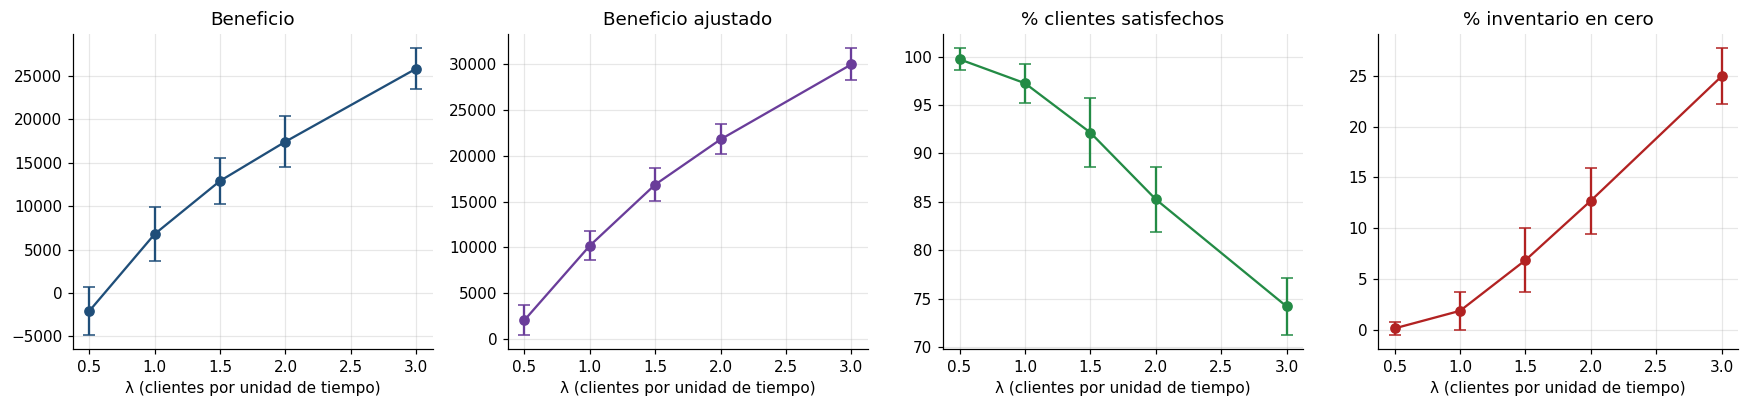

In [11]:
fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, col, color in zip(axs, ["Beneficio", "Beneficio ajustado", "% clientes satisfechos", "% inventario en cero"],
                          ["#1f4e79", "#6a3d9a", "#238b45", "#b22222"]):
    ax.errorbar(sens.index, sens[col], yerr=sens[col + " (desv.)"], fmt="o-", color=color, capsize=4)
    ax.set_xlabel("λ (clientes por unidad de tiempo)"); ax.set_title(col)
plt.tight_layout(); guardar("53_lambda"); plt.show()


### Análisis

**Una sola corrida no alcanza para evaluar el beneficio.** En las 30 réplicas con $\lambda = 1$ el beneficio
fue $6.799{,}61 \pm 3.063{,}02$ (media $\pm$ desviación), con un intervalo del 95 % de $[5.655{,}86;\ 7.943{,}36]$.
La corrida principal (1.121,70) quedó muy por debajo por la mala suerte del pedido de fin de periodo. Buena parte de
la variabilidad viene de ese efecto de borde: el beneficio ajustado tiene la mitad de desviación
(1.549,03), con intervalo $[9.611{,}20;\ 10.768{,}03]$. Esto sugiere que la política debería considerar el
horizonte, por ejemplo no pedir si faltan menos de $L$ unidades de tiempo para cerrar.

**Con $\lambda = 1$ la política $(p = 20, P = 100)$ da un servicio alto:** 97,27 % de clientes satisfechos
(IC 95 %: 96,51 a 98,02) y el inventario en cero solo el 1,92 % del tiempo. La razón es que durante los
$L = 5$ unidades de tiempo de espera de un pedido se demandan en promedio $\lambda L\,E[D] = 1 \cdot 5 \cdot 3 = 15$ unidades,
menos que las 20 con que se dispara el pedido. Solo cuando la demanda de ese plazo sale alta hay
faltantes, como pasó en la corrida principal.

**El efecto de $\lambda$ confirma ese razonamiento.** La demanda esperada durante el plazo de entrega es
$15\lambda$, que supera el punto de reorden $p = 20$ cuando $\lambda > 4/3$. En la tabla se ve el quiebre justo
ahí: el porcentaje de tiempo sin inventario pasa de 1,9 % con $\lambda = 1$ a 6,9 % con $\lambda = 1{,}5$, 12,7 %
con $\lambda = 2$ y 24,9 % con $\lambda = 3$, y los clientes satisfechos bajan de 97,3 % a 74,2 %. El beneficio sí
sube con $\lambda$, de $-2.072$ a 25.865, porque se venden más unidades con un margen de 50 cada una. Pero
con $\lambda = 3$ uno de cada cuatro clientes se va sin su pedido completo, y eso es venta perdida y clientes
molestos.

**Con poca demanda el negocio pierde.** Con $\lambda = 0{,}5$ el beneficio medio fue negativo ($-2.072$). En
promedio se vendieron 152 unidades por 22.780, pero los pedidos costaron 19.307 y el almacenamiento 5.546: con
tan poca demanda, cada pedido de unas 80 unidades tarda unas 53 unidades de tiempo en venderse. Además, se terminó con 61
unidades sin vender en promedio. El beneficio ajustado sí es positivo (2.048), pero es el más bajo de la
tabla. Para ese nivel de demanda convendría un $P$ más bajo.

**Conclusión práctica.** Con los valores de la guía, $p = 20$ solo es adecuado si llegan a lo sumo unos 1,3
clientes por unidad de tiempo. Para demandas mayores habría que subir el punto de reorden al menos a $15\lambda$
más un margen de seguridad, o conseguir un proveedor con menor $L$. El modelo permite probar esas políticas
cambiando dos parámetros, que es justamente el uso que el libro le da: redefinir la política de gestión del
inventario.
